In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, RMSprop, SGD

tf.random.set_seed(42)
np.random.seed(42)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

df = pd.read_csv('/Users/nikitadyshko/Desktop/курсы/3 year/2semestr/Deep Learning/Laba1/heart.csv')
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Глобальный список для сбора результатов 
results_list = []

results_list1 = []
def train_and_evaluate(model, name, epochs=100, callbacks=None, optimizer='adam'):
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, validation_data=(X_test, y_test), 
                        epochs=epochs, batch_size=32, verbose=0, callbacks=callbacks)
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    
    ax[0].plot(history.history['loss'], label='Train Loss', color='blue')
    ax[0].plot(history.history['val_loss'], label='Val Loss', color='red')
    ax[0].set_title(f'{name} - Функция потерь (Loss)')
    ax[0].set_xlabel('Эпохи')
    ax[0].set_ylabel('Loss')
    ax[0].legend()
    ax[0].grid(True)
    
    ax[1].plot(history.history['accuracy'], label='Train Acc', color='blue')
    ax[1].plot(history.history['val_accuracy'], label='Val Acc', color='red')
    ax[1].set_title(f'{name} - Точность (Accuracy)')
    ax[1].set_xlabel('Эпохи')
    ax[1].set_ylabel('Accuracy')
    ax[1].legend()
    ax[1].grid(True)
    
    plt.show()
    
    results_list.append({
        'Model': name,
        'Train Loss': round(history.history['loss'][-1], 4),
        'Val Loss': round(history.history['val_loss'][-1], 4),
        'Train Acc': round(history.history['accuracy'][-1], 4),
        'Val Acc': round(history.history['val_accuracy'][-1], 4)
    })
    
    results_list1.append({
        'Model': name,
        'Train Loss': round(history.history['loss'][-1], 4),
        'Val Loss': round(history.history['val_loss'][-1], 4),
        'Train Acc': round(history.history['accuracy'][-1], 4),
        'Val Acc': round(history.history['val_accuracy'][-1], 4)
    })
    
    return history

БАЗОВАЯ МОДЕЛЬ (ПЕРЕОБУЧЕНИЕ)


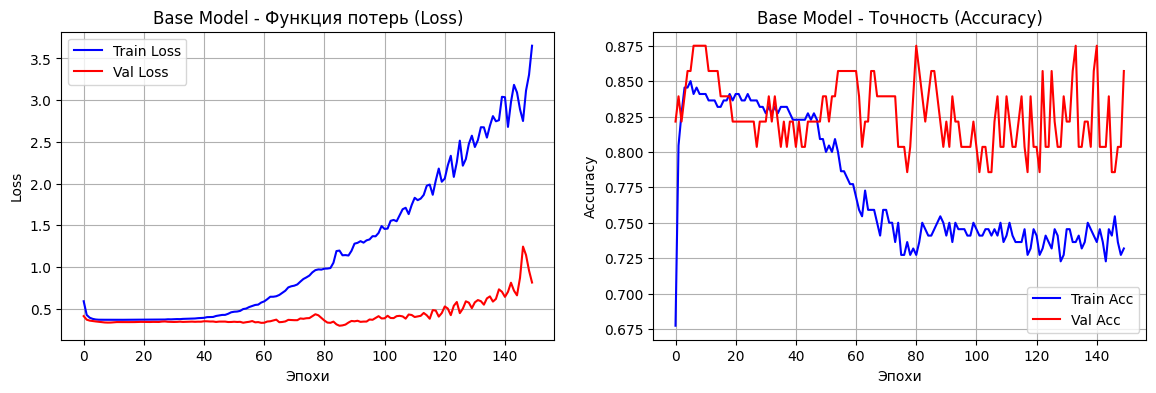

In [43]:
def get_base_model():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    return model

print("="*50)
print("БАЗОВАЯ МОДЕЛЬ (ПЕРЕОБУЧЕНИЕ)")
print("="*50)
base_history = train_and_evaluate(get_base_model(), "Base Model", epochs=150)

ЗАДАНИЕ 1: L2-РЕГУЛЯРИЗАЦИЯ


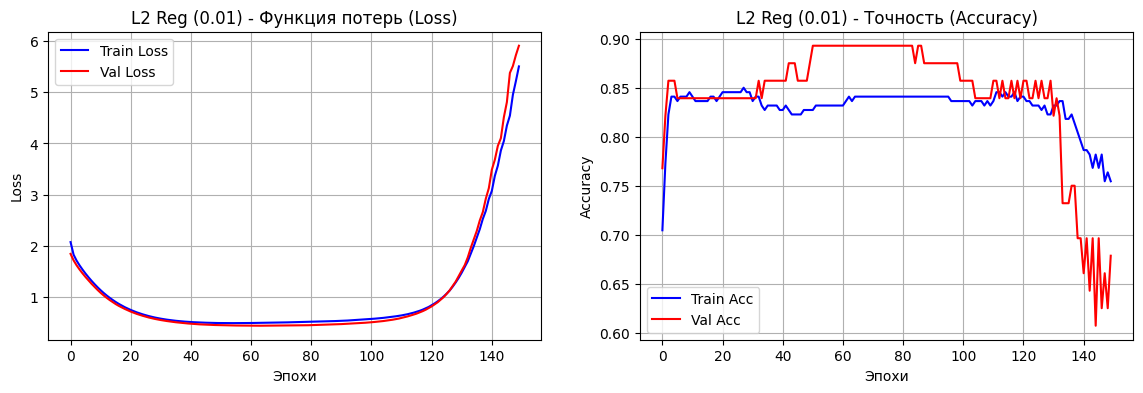

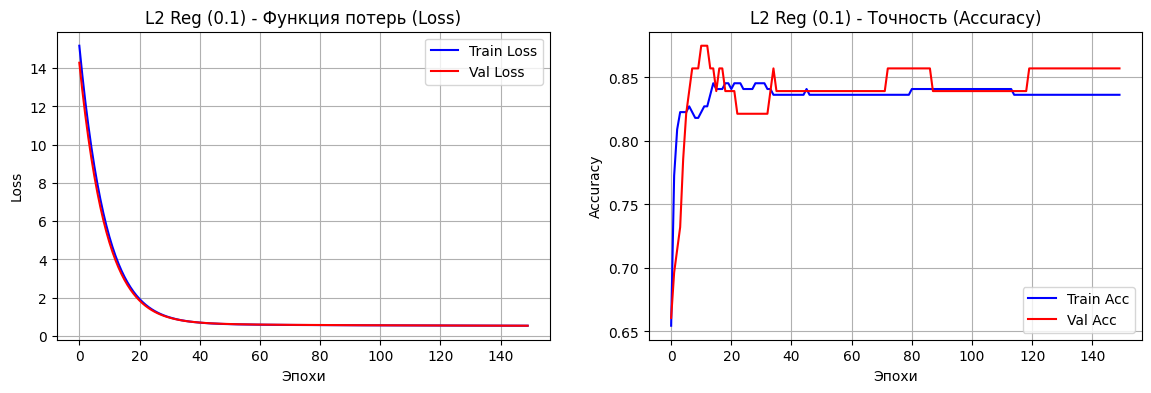

In [44]:
def get_l2_model(l2_rate):
    model = Sequential([
        Dense(128, activation='relu', kernel_regularizer=l2(l2_rate), input_shape=(X_train.shape[1],)),
        Dense(64, activation='relu', kernel_regularizer=l2(l2_rate)),
        Dense(32, activation='relu', kernel_regularizer=l2(l2_rate)),
        Dense(1, activation='sigmoid')
    ])
    return model

print("="*50)
print("ЗАДАНИЕ 1: L2-РЕГУЛЯРИЗАЦИЯ")
print("="*50)
train_and_evaluate(get_l2_model(0.01), "L2 Reg (0.01)", epochs=150)
train_and_evaluate(get_l2_model(0.1), "L2 Reg (0.1)", epochs=150)

ЗАДАНИЕ 2: DROPOUT


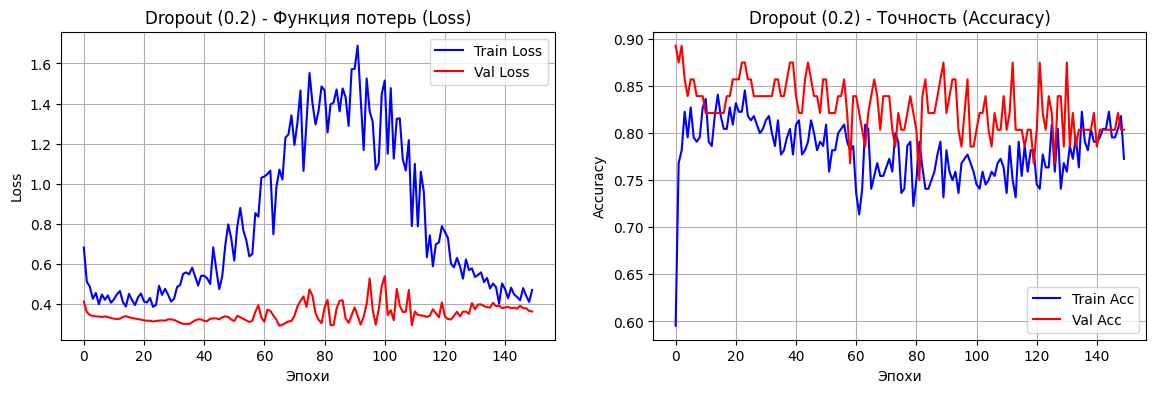

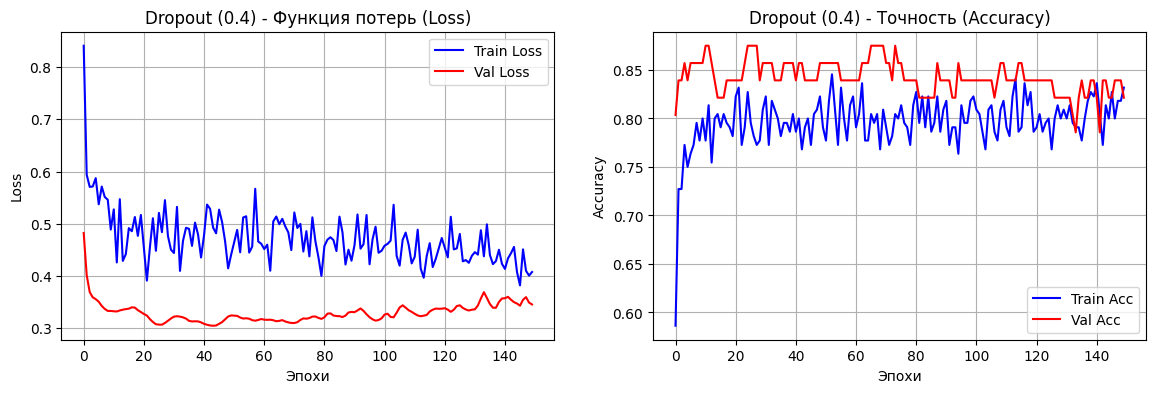

In [45]:
def get_dropout_model(drop_rate):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        Dropout(drop_rate),
        Dense(64, activation='relu'),
        Dropout(drop_rate),
        Dense(32, activation='relu'),
        Dropout(drop_rate),
        Dense(1, activation='sigmoid')
    ])
    return model

print("="*50)
print("ЗАДАНИЕ 2: DROPOUT")
print("="*50)
train_and_evaluate(get_dropout_model(0.2), "Dropout (0.2)", epochs=150)
train_and_evaluate(get_dropout_model(0.4), "Dropout (0.4)", epochs=150)

ЗАДАНИЕ 3: BATCH NORMALIZATION


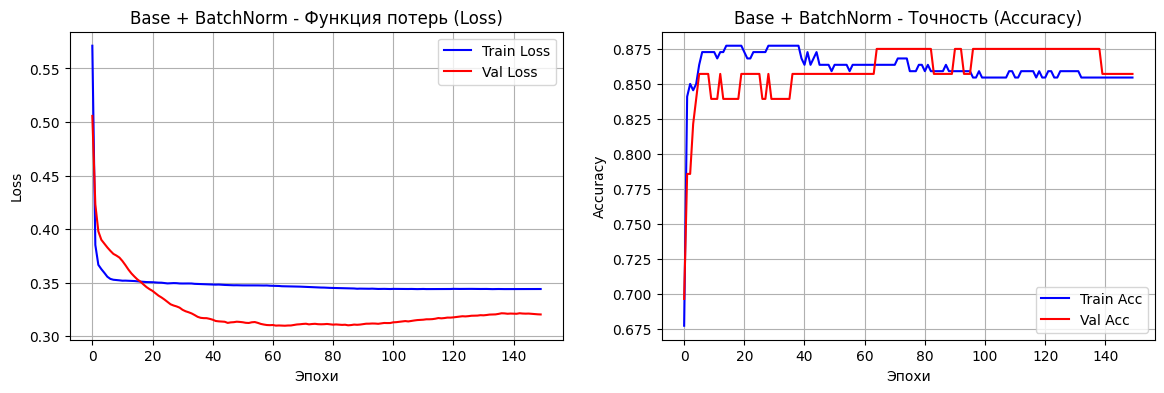

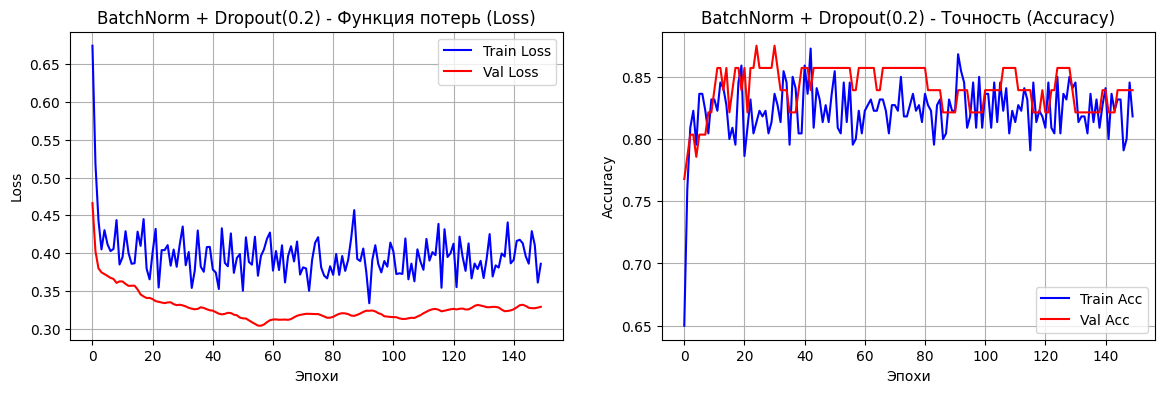

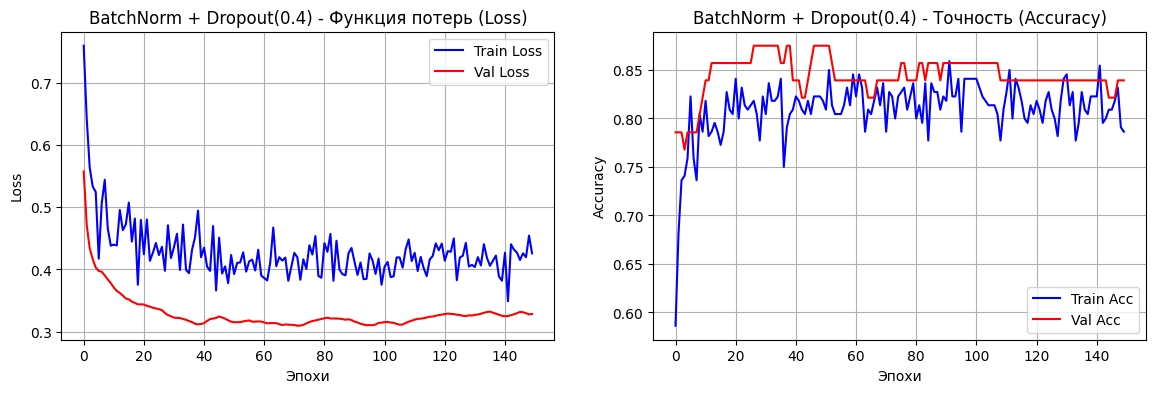

In [46]:
def get_bn_model():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dense(1, activation='sigmoid')
    ])
    return model

def get_dropout_bn_model(drop_rate):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dropout(drop_rate),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(drop_rate),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(drop_rate),
        Dense(1, activation='sigmoid')
    ])
    return model

print("="*50)
print("ЗАДАНИЕ 3: BATCH NORMALIZATION")
print("="*50)
train_and_evaluate(get_bn_model(), "Base + BatchNorm", epochs=150)
train_and_evaluate(get_dropout_bn_model(0.2), "BatchNorm + Dropout(0.2)", epochs=150)
train_and_evaluate(get_dropout_bn_model(0.4), "BatchNorm + Dropout(0.4)", epochs=150)

ЗАДАНИЕ 4: EARLY STOPPING


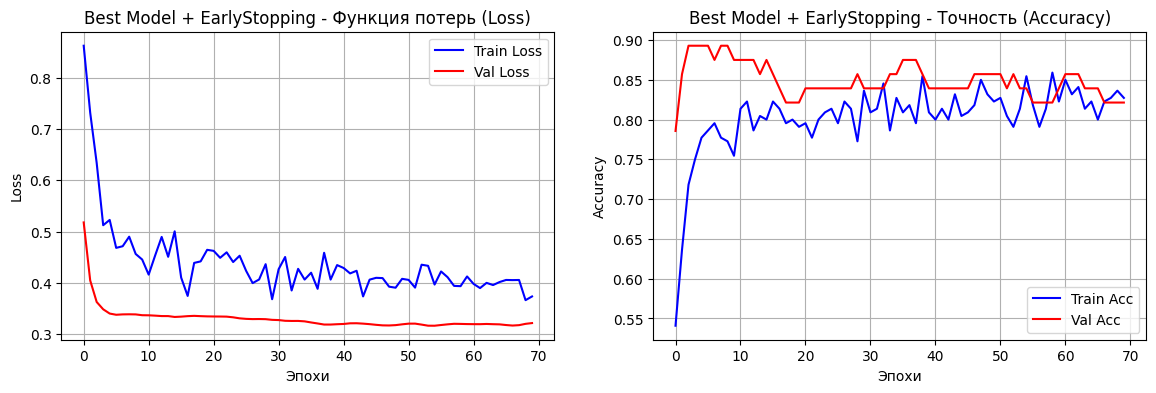

Обучение эффективно остановлено на эпохе: 70


In [ ]:
print("="*50)
print("ЗАДАНИЕ 4: EARLY STOPPING")
print("="*50)

early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=15,
    restore_best_weights=True
)

best_model = get_dropout_bn_model(0.4)
history_es = train_and_evaluate(best_model, "Best Model + EarlyStopping", epochs=200, callbacks=[early_stopping])

stopped_epoch = len(history_es.history['loss'])
print(f"Обучение эффективно остановлено на эпохе: {stopped_epoch}")

In [ ]:
import time
import gc
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

print("="*60)
print("ЗАДАНИЕ 6.1: GRID SEARCH")
print("="*60)

tf.keras.backend.clear_session()
gc.collect()

def create_tuned_model(neurons=64, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Dense(neurons, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(max(32, neurons // 2), activation='relu'), 
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

model_wrap = KerasClassifier(
    model=create_tuned_model,
    neurons=64,
    dropout_rate=0.2,
    learning_rate=0.001,
    epochs=20, 
    batch_size=32,
    verbose=0
)

param_grid = {
    'learning_rate': [0.001, 0.01, 0.1],
    'batch_size': [32, 64, 128],
    'neurons': [64, 128, 256],
    'dropout_rate': [0.2, 0.3, 0.5]
}

print("Запуск Grid Search (полный перебор, ожидайте)...")
grid = GridSearchCV(estimator=model_wrap, param_grid=param_grid, cv=2, n_jobs=1)

start_time = time.time()
grid_result = grid.fit(X_train, y_train)
grid_time = time.time() - start_time

print(f"✅ Grid Search завершен за {grid_time:.2f} сек.")
print(f"Лучшие параметры Grid: {grid_result.best_params_}")

best_keras_model_grid = grid_result.best_estimator_.model_
train_loss, train_acc = best_keras_model_grid.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc = best_keras_model_grid.evaluate(X_test, y_test, verbose=0)

results_list.append({
    'name': 'Best Model (GridSearch)',
    'train_loss': round(train_loss, 4),
    'val_loss': round(val_loss, 4),
    'train_accuracy': round(train_acc, 4),
    'val_accuracy': round(val_acc, 4),
    'diff_loss': round(val_loss - train_loss, 4),
    'diff_accuracy': round(train_acc - val_acc, 4)
})

del grid
tf.keras.backend.clear_session()
gc.collect()

ЗАДАНИЕ 6.1: GRID SEARCH
Запуск Grid Search (полный перебор, ожидайте)...
✅ Grid Search завершен за 1809.59 сек.
Лучшие параметры Grid: {'batch_size': 64, 'dropout_rate': 0.2, 'learning_rate': 0.1, 'neurons': 128}


0

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

print("="*60)
print("ЗАДАНИЕ 6.2: RANDOM SEARCH")
print("="*60)

tf.keras.backend.clear_session()
gc.collect()

print("Запуск Random Search (20 итераций)...")
random_search = RandomizedSearchCV(estimator=model_wrap, param_distributions=param_grid, 
                                   n_iter=20, cv=2, n_jobs=1, random_state=42)

start_time = time.time()
random_result = random_search.fit(X_train, y_train)
random_time = time.time() - start_time

print(f"✅ Random Search завершен за {random_time:.2f} сек.")
print(f"Лучшие параметры Random: {random_result.best_params_}")

# Записываем результаты в глобальный список
best_keras_model_random = random_result.best_estimator_.model_
train_loss_r, train_acc_r = best_keras_model_random.evaluate(X_train, y_train, verbose=0)
val_loss_r, val_acc_r = best_keras_model_random.evaluate(X_test, y_test, verbose=0)

results_list.append({
    'name': 'Best Model (RandomSearch)',
    'train_loss': round(train_loss_r, 4),
    'val_loss': round(val_loss_r, 4),
    'train_accuracy': round(train_acc_r, 4),
    'val_accuracy': round(val_acc_r, 4),
    'diff_loss': round(val_loss_r - train_loss_r, 4),
    'diff_accuracy': round(train_acc_r - val_acc_r, 4)
})

best_model_for_cv = random_result.best_estimator_

del random_search
tf.keras.backend.clear_session()
gc.collect()

ЗАДАНИЕ 6.2: RANDOM SEARCH
Запуск Random Search (20 итераций)...
✅ Random Search завершен за 950.87 сек.
Лучшие параметры Random: {'neurons': 64, 'learning_rate': 0.1, 'dropout_rate': 0.2, 'batch_size': 64}


0

In [ ]:
from sklearn.model_selection import cross_val_score

print("="*60)
print("ЗАДАНИЕ 7: КРОСС-ВАЛИДАЦИЯ (k=3)")
print("="*60)

# Берем лучшую модель
best_model_cv = grid_result.best_estimator_

X_full = np.vstack((X_train, X_test))
y_full = np.concatenate((y_train, y_test))

print("Запуск кросс-валидации (k=3)...")
cv_scores = cross_val_score(best_model_cv, X_full, y_full, cv=3)

print("\nРезультаты кросс-валидации:")
print(f"Точность на каждом фолде: {cv_scores}")
print(f"Средняя точность модели: {cv_scores.mean():.4f}")
print(f"Стандартное отклонение: {cv_scores.std():.4f}")

if cv_scores.std() < 0.05:
    print("Вывод: Модель стабильна, разброс качества между фолдами небольшой.")
else:
    print("Вывод: Присутствует нестабильность, качество сильно зависит от разбиения данных.")

ЗАДАНИЕ 7: КРОСС-ВАЛИДАЦИЯ (k=3)
Запуск кросс-валидации (k=3)...

Результаты кросс-валидации:
Точность на каждом фолде: [0.85869565 0.79347826 0.81521739]
Средняя точность модели: 0.8225
Стандартное отклонение: 0.0271
Вывод: Модель стабильна, разброс качества между фолдами небольшой.


In [ ]:
print("="*50)
print("ЗАДАНИЕ 5: ОТЧЕТ CSV")
print("="*50)

results_df = pd.DataFrame(results_list)

display(results_df)

csv_filename = 'lab2_results_report.csv'
results_df.to_csv(csv_filename, index=False)
print(f"\n✅ Отчет успешно сохранен в файл: {csv_filename}")

ЗАДАНИЕ 5: ОТЧЕТ CSV


,Model,Train Loss,Val Loss,Train Acc,Val Acc
0,Base Model,3.6520,0.8148,0.7318,0.8571
1,L2 Reg (0.01),5.5024,5.9062,0.7545,0.6786
2,L2 Reg (0.1),0.5335,0.5332,0.8364,0.8571
3,Dropout (0.2),0.4691,0.3612,0.7727,0.8036
4,Dropout (0.4),0.4075,0.3453,0.8318,0.8214
5,Base + BatchNorm,0.3441,0.3204,0.8545,0.8571
6,BatchNorm + Dropout(0.2),0.3858,0.3288,0.8182,0.8393
7,BatchNorm + Dropout(0.4),0.4260,0.3282,0.7864,0.8393
8,Best Model + EarlyStopping,0.3738,0.3219,0.8273,0.8214



✅ Отчет успешно сохранен в файл: lab2_results_report.csv
